# Notebook 01: Data Exploration
**Ship of Theseus NLP Project**

Exploratory analysis of the corpus before running any similarity metrics.
Goal: understand corpus structure, text characteristics, vocabulary patterns,
and source author profiles.

**Prerequisite:** `python -m src.data.prepare_corpus`

## 1. Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.utils.config import (
    ALL_DATASETS, PARAPHRASERS, PARAPHRASER_FAMILIES,
    TIER_PALETTE, PARAPHRASER_PALETTE, SOURCE_PALETTE,
    FIGURES_DIR, DATA_PROCESSED,
)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.2)

corpus = pd.read_parquet(DATA_PROCESSED / "corpus_full.parquet")
print(f"Corpus: {len(corpus):,} rows, {len(corpus.columns)} columns")
print(f"Columns: {list(corpus.columns)}")

Corpus: 66,400 rows, 15 columns
Columns: ['source', 'key', 'text', 'version_name', 'dataset', 'split', 'tier', 'paraphraser', 'paraphraser_name', 'word_count', 'char_count', 'sentence_count', 'avg_word_length', 'ttr', 'punct_density']


## 2. Corpus Structure
How big is each dataset? Are all tier/source/paraphraser combos present?

### 2a. Dataset sizes

In [2]:
print("Rows per dataset:")
print(corpus["dataset"].value_counts().sort_index().to_string())

print(f"\nTiers:")
print(corpus["tier"].value_counts().sort_index().to_string())

print(f"\nParaphrasers:")
print(corpus["paraphraser_name"].value_counts().to_string())

print(f"\nSources:")
print(corpus["source"].value_counts().to_string())

Rows per dataset:
dataset
cmv         5626
eli5       10447
sci_gen    10360
tldr        8404
wp         10289
xsum       10472
yelp       10802

Tiers:
tier
T0     3020
T1    21130
T2    21126
T3    21124

Paraphrasers:
paraphraser_name
ChatGPT             9060
Pegasus (Full)      9060
Dipper              9060
Pegasus (Slight)    9060
Dipper (Low)        9060
Dipper (High)       9060
PaLM2               9020
original            3020

Sources:
source
OpenAI         16248
Human          10127
Tsinghua        9656
LLAMA           8632
BigScience      8034
PaLM            7725
Eleuther-AI     5978


### 2b. Version-to-tier mapping
Sanity check: are all 22 version strings mapped correctly?

In [3]:
version_map = (corpus[["version_name", "tier", "paraphraser_name"]]
               .drop_duplicates()
               .sort_values(["paraphraser_name", "tier"]))
for _, row in version_map.iterrows():
    print(f"  {row['version_name']:55s} -> {row['tier']}  ({row['paraphraser_name']})")

  chatgpt                                                 -> T1  (ChatGPT)
  chatgpt_chatgpt                                         -> T2  (ChatGPT)
  chatgpt_chatgpt_chatgpt                                 -> T3  (ChatGPT)
  dipper                                                  -> T1  (Dipper)
  dipper_dipper                                           -> T2  (Dipper)
  dipper_dipper_dipper                                    -> T3  (Dipper)
  dipper(high)                                            -> T1  (Dipper (High))
  dipper(high)_dipper(high)                               -> T2  (Dipper (High))
  dipper(high)_dipper(high)_dipper(high)                  -> T3  (Dipper (High))
  dipper(low)                                             -> T1  (Dipper (Low))
  dipper(low)_dipper(low)                                 -> T2  (Dipper (Low))
  dipper(low)_dipper(low)_dipper(low)                     -> T3  (Dipper (Low))
  palm                                                    -> T1  (PaLM

### 2c. Missing data check
Are all (dataset, source, paraphraser, tier) combinations present?

In [4]:
print("Null counts per column:")
print(corpus.isnull().sum().to_string())

# Check for empty text
empty_text = corpus[corpus["text"].str.strip() == ""]
print(f"\nEmpty text rows: {len(empty_text)}")

# Check tier x paraphraser completeness
print("\nSamples per tier x paraphraser:")
ct = pd.crosstab(corpus["paraphraser_name"], corpus["tier"])
print(ct.to_string())

Null counts per column:
source              0
key                 0
text                0
version_name        0
dataset             0
split               0
tier                0
paraphraser         0
paraphraser_name    0
word_count          0
char_count          0
sentence_count      0
avg_word_length     0
ttr                 0
punct_density       0

Empty text rows: 0

Samples per tier x paraphraser:
tier                T0    T1    T2    T3
paraphraser_name                        
ChatGPT              0  3020  3020  3020
Dipper               0  3020  3020  3020
Dipper (High)        0  3020  3020  3020
Dipper (Low)         0  3020  3020  3020
PaLM2                0  3010  3006  3004
Pegasus (Full)       0  3020  3020  3020
Pegasus (Slight)     0  3020  3020  3020
original          3020     0     0     0


### 2d. Cross-tabulation heatmap
Sample counts across dataset x paraphraser.

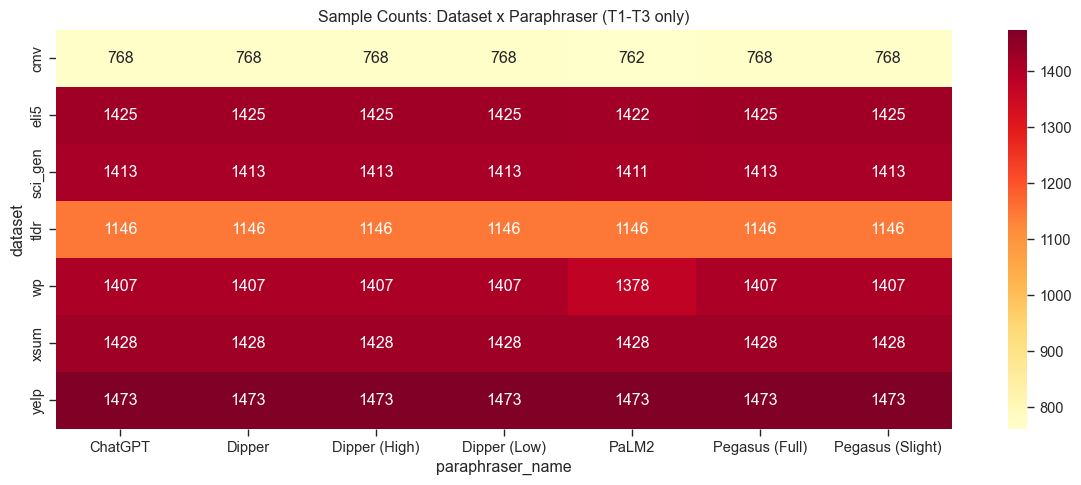

In [5]:
# Exclude T0 originals since they're shared across paraphrasers
para_only = corpus[corpus["tier"] != "T0"]

ct_dp = pd.crosstab(para_only["dataset"], para_only["paraphraser_name"])

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(ct_dp, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_title("Sample Counts: Dataset x Paraphraser (T1-T3 only)")
plt.tight_layout()
(FIGURES_DIR / "eda").mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "eda" / "dataset_paraphraser_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 3. Text Characteristics by Tier
How do basic text properties shift across paraphrase iterations?

### 3a. Word count distributions

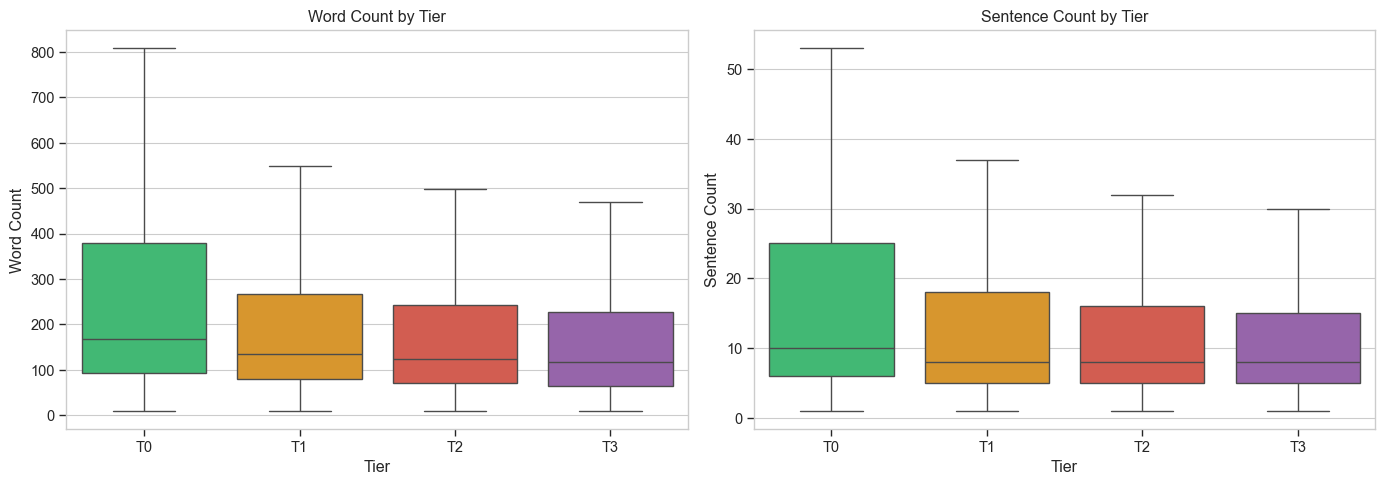

Mean word count by tier:
tier
T0    278.7
T1    220.6
T2    198.1
T3    183.5


In [6]:
tiers = ["T0", "T1", "T2", "T3"]
plot_data = corpus[corpus["tier"].isin(tiers)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count by tier
sns.boxplot(data=plot_data, x="tier", y="word_count", order=tiers,
            palette=TIER_PALETTE, ax=axes[0], showfliers=False)
axes[0].set_title("Word Count by Tier")
axes[0].set_xlabel("Tier"); axes[0].set_ylabel("Word Count")

# Sentence count by tier
sns.boxplot(data=plot_data, x="tier", y="sentence_count", order=tiers,
            palette=TIER_PALETTE, ax=axes[1], showfliers=False)
axes[1].set_title("Sentence Count by Tier")
axes[1].set_xlabel("Tier"); axes[1].set_ylabel("Sentence Count")

plt.tight_layout()
plt.show()

print("Mean word count by tier:")
print(plot_data.groupby("tier")["word_count"].mean().round(1).to_string())

### 3b. Do paraphrasers change text length?
Comparing word count shift across paraphrasers at each tier.

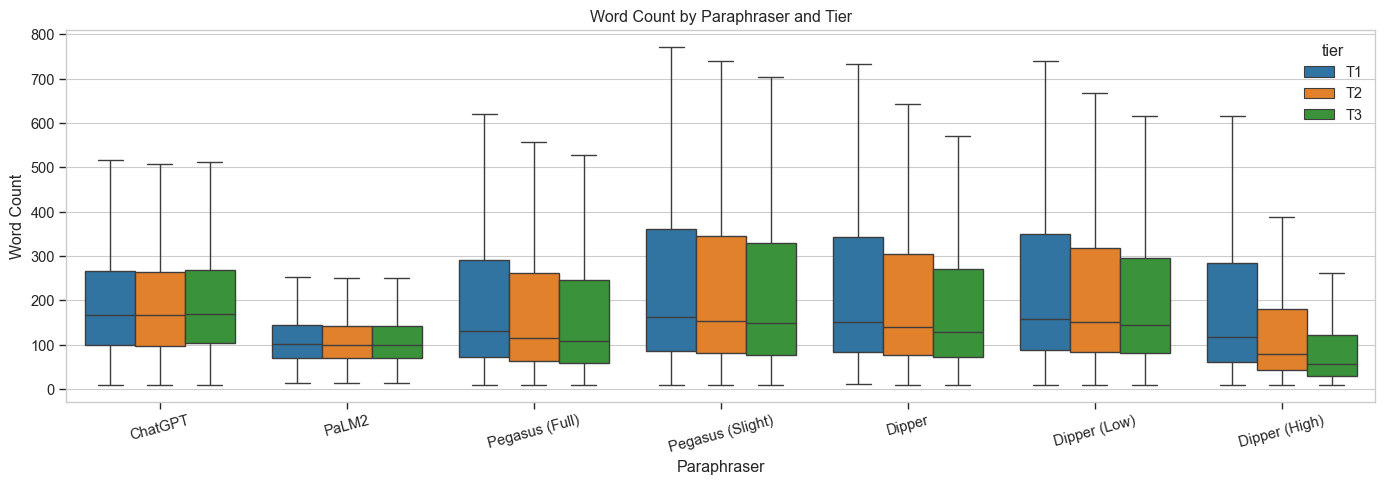

In [7]:
para_data = plot_data[plot_data["tier"] != "T0"]

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=para_data, x="paraphraser_name", y="word_count",
            hue="tier", hue_order=["T1", "T2", "T3"],
            ax=ax, showfliers=False)
ax.set_title("Word Count by Paraphraser and Tier")
ax.set_xlabel("Paraphraser"); ax.set_ylabel("Word Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda" / "word_count_by_paraphraser_tier.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 3c. Average sentence length
Words per sentence -- a basic stylometric signal.

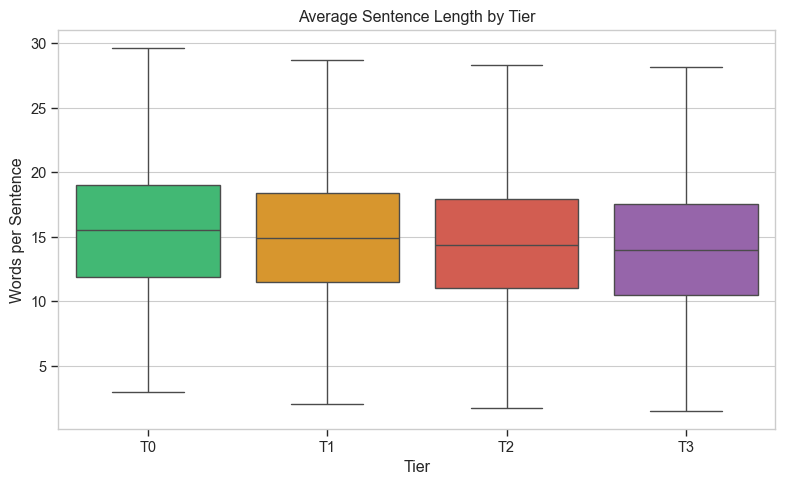

Mean words/sentence by tier:
tier
T0    16.00
T1    15.45
T2    14.89
T3    14.55


In [8]:
plot_data = plot_data.copy()
plot_data["avg_sent_len"] = plot_data["word_count"] / plot_data["sentence_count"].clip(lower=1)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=plot_data, x="tier", y="avg_sent_len", order=tiers,
            palette=TIER_PALETTE, ax=ax, showfliers=False)
ax.set_title("Average Sentence Length by Tier")
ax.set_xlabel("Tier"); ax.set_ylabel("Words per Sentence")
plt.tight_layout()
plt.show()

print("Mean words/sentence by tier:")
print(plot_data.groupby("tier")["avg_sent_len"].mean().round(2).to_string())

## 4. Vocabulary Analysis
How does lexical diversity and punctuation usage change through the paraphrase chain?

### 4a. Type-Token Ratio by tier and paraphraser

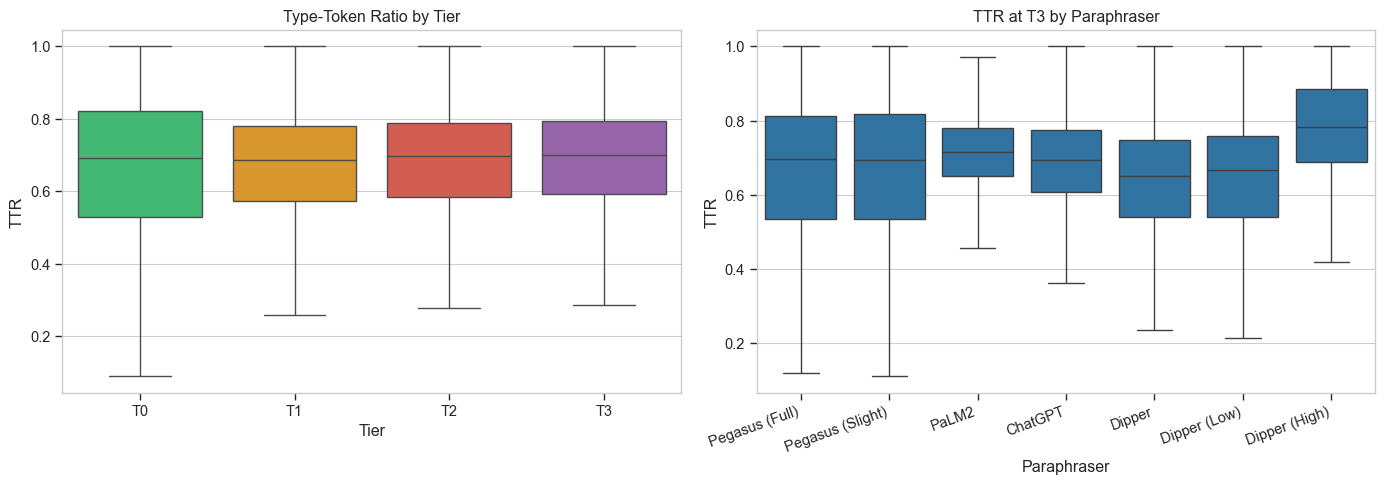

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TTR by tier
sns.boxplot(data=plot_data, x="tier", y="ttr", order=tiers,
            palette=TIER_PALETTE, ax=axes[0], showfliers=False)
axes[0].set_title("Type-Token Ratio by Tier")
axes[0].set_xlabel("Tier"); axes[0].set_ylabel("TTR")

# TTR by paraphraser (T3 only, for clearest signal)
t3_data = corpus[corpus["tier"] == "T3"]
sns.boxplot(data=t3_data, x="paraphraser_name", y="ttr",
            ax=axes[1], showfliers=False)
axes[1].set_title("TTR at T3 by Paraphraser")
axes[1].set_xlabel("Paraphraser"); axes[1].set_ylabel("TTR")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda" / "ttr_by_tier_and_paraphraser.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 4b. Punctuation patterns
Do paraphrasers strip out expressive punctuation?

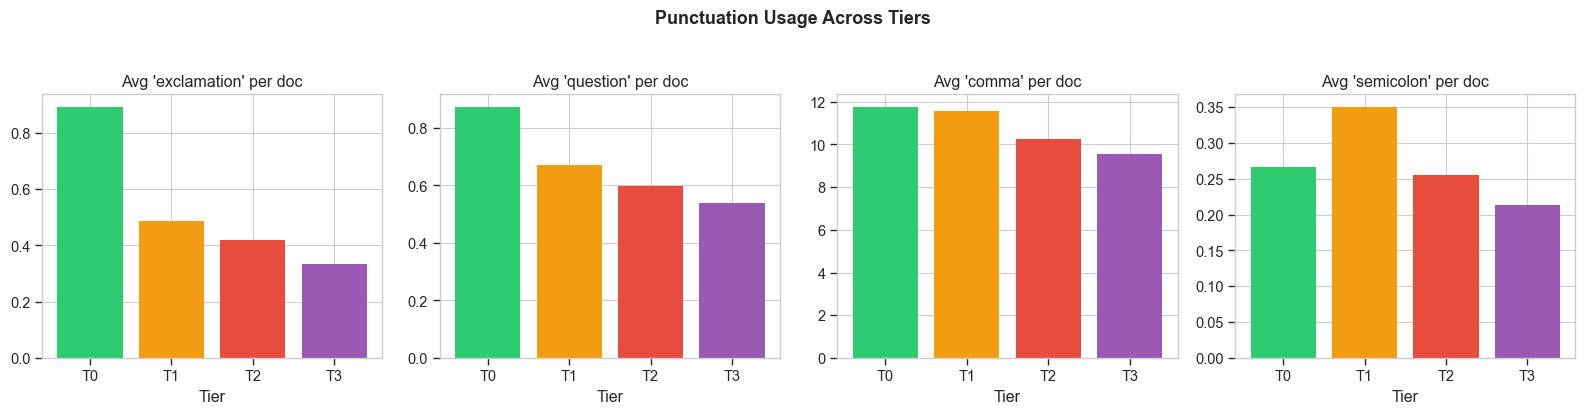

In [10]:
def count_punct(text, char):
    return text.count(char)

# Count specific punctuation marks per document
punct_data = plot_data[["tier", "text"]].copy()
for char, name in [("!", "exclamation"), ("?", "question"),
                    (",", "comma"), (";", "semicolon")]:
    punct_data[name] = punct_data["text"].apply(lambda t: count_punct(t, char))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, name in enumerate(["exclamation", "question", "comma", "semicolon"]):
    means = punct_data.groupby("tier")[name].mean().reindex(tiers)
    axes[i].bar(tiers, means, color=[TIER_PALETTE[t] for t in tiers])
    axes[i].set_title(f"Avg '{name}' per doc")
    axes[i].set_xlabel("Tier")

plt.suptitle("Punctuation Usage Across Tiers", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda" / "punctuation_by_tier.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 4c. Punctuation density by paraphraser
Which paraphraser strips the most punctuation?

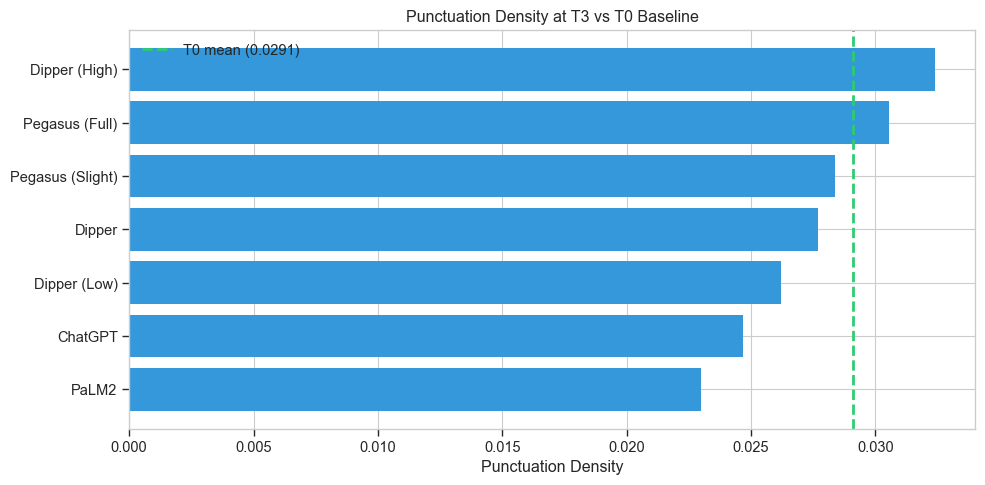

In [11]:
# Compare T0 avg to T3 avg per paraphraser
t0_punct = corpus[corpus["tier"] == "T0"]["punct_density"].mean()

t3_punct = (corpus[corpus["tier"] == "T3"]
            .groupby("paraphraser_name")["punct_density"].mean()
            .sort_values())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(t3_punct.index, t3_punct.values, color="#3498db")
ax.axvline(t0_punct, color="#2ecc71", linewidth=2, linestyle="--", label=f"T0 mean ({t0_punct:.4f})")
ax.set_xlabel("Punctuation Density")
ax.set_title("Punctuation Density at T3 vs T0 Baseline")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda" / "punct_density_t3_vs_t0.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 4d. Word frequency shift: T0 vs T3
What are the most common words before and after paraphrasing?

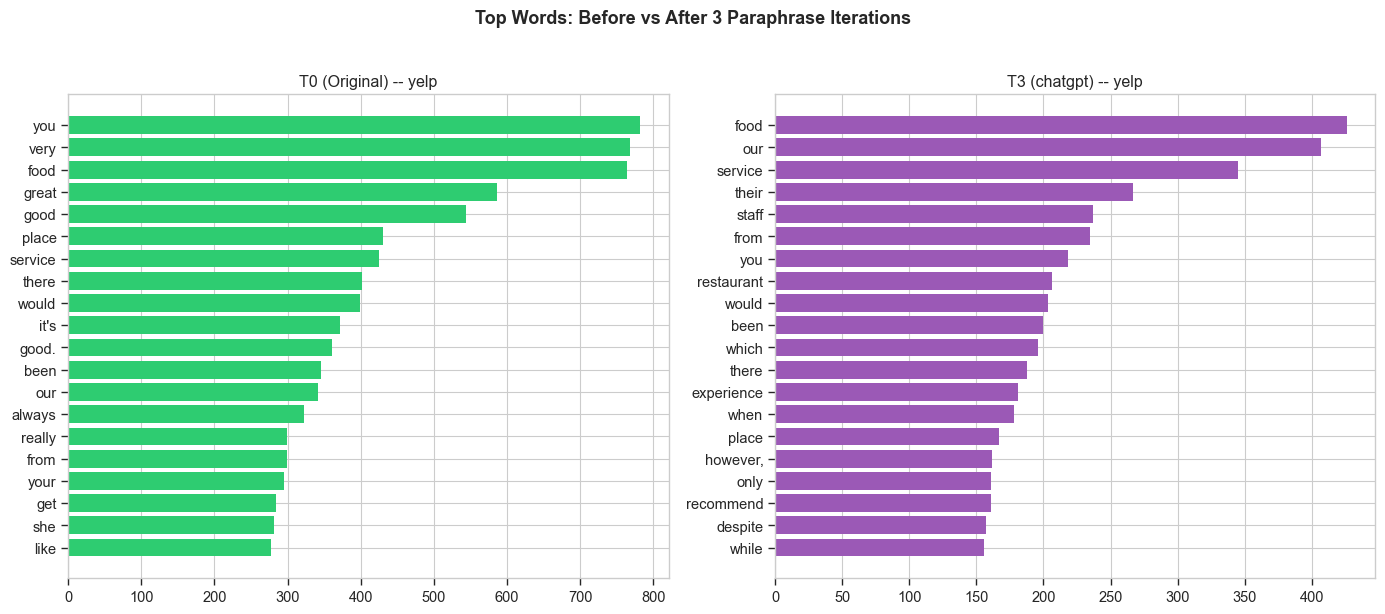

In [12]:
# Pick one dataset for focused comparison
sample_ds = "yelp"
sample_para = "chatgpt"

t0_texts = corpus[(corpus["tier"] == "T0") & (corpus["dataset"] == sample_ds)]["text"]
t3_texts = corpus[(corpus["tier"] == "T3") & (corpus["dataset"] == sample_ds)
                  & (corpus["paraphraser"] == sample_para)]["text"]

def top_words(texts, n=20):
    words = " ".join(texts).lower().split()
    # Skip very common stopwords for cleaner signal
    stop = {"the", "a", "an", "and", "or", "is", "was", "were", "are", "to",
            "of", "in", "for", "on", "it", "that", "this", "with", "i", "my",
            "we", "they", "be", "have", "has", "had", "not", "but", "at", "by"}
    words = [w for w in words if w not in stop and len(w) > 2]
    return Counter(words).most_common(n)

t0_top = top_words(t0_texts)
t3_top = top_words(t3_texts)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

words_0, counts_0 = zip(*t0_top)
axes[0].barh(range(len(words_0)), counts_0, color="#2ecc71")
axes[0].set_yticks(range(len(words_0))); axes[0].set_yticklabels(words_0)
axes[0].invert_yaxis()
axes[0].set_title(f"T0 (Original) -- {sample_ds}")

words_3, counts_3 = zip(*t3_top)
axes[1].barh(range(len(words_3)), counts_3, color="#9b59b6")
axes[1].set_yticks(range(len(words_3))); axes[1].set_yticklabels(words_3)
axes[1].invert_yaxis()
axes[1].set_title(f"T3 ({sample_para}) -- {sample_ds}")

plt.suptitle("Top Words: Before vs After 3 Paraphrase Iterations",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda" / "top_words_t0_vs_t3.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 5. Source Author Profiles
The corpus has 7 sources (1 Human + 6 LLMs). How do they differ at T0 before any paraphrasing?

In [13]:
t0_data = corpus[corpus["tier"] == "T0"]

print(f"T0 documents: {len(t0_data):,}")
print(f"\nBy source:")
print(t0_data["source"].value_counts().to_string())

T0 documents: 3,020

By source:
source
Human          511
OpenAI         468
LLAMA          464
Tsinghua       447
BigScience     428
PaLM           378
Eleuther-AI    324


### 5a. Text length by source

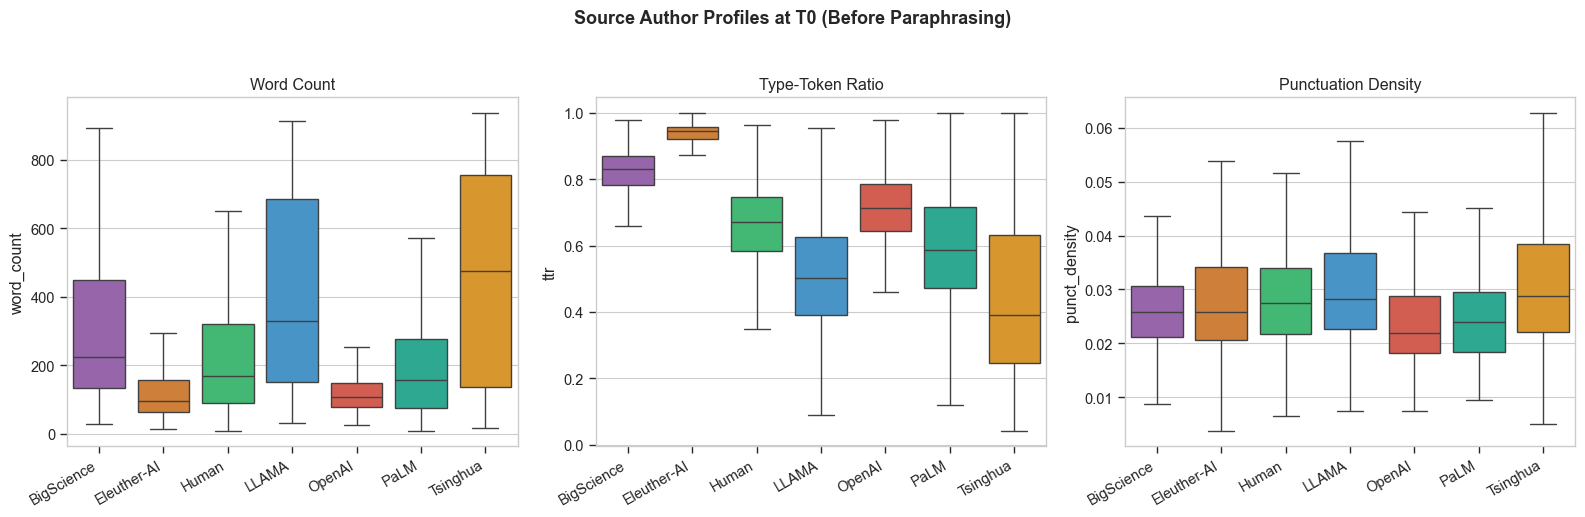

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

source_order = sorted(t0_data["source"].unique())
colors = [SOURCE_PALETTE.get(s, "#95a5a6") for s in source_order]

sns.boxplot(data=t0_data, x="source", y="word_count", order=source_order,
            palette=colors, ax=axes[0], showfliers=False)
axes[0].set_title("Word Count"); axes[0].set_xlabel("")
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

sns.boxplot(data=t0_data, x="source", y="ttr", order=source_order,
            palette=colors, ax=axes[1], showfliers=False)
axes[1].set_title("Type-Token Ratio"); axes[1].set_xlabel("")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

sns.boxplot(data=t0_data, x="source", y="punct_density", order=source_order,
            palette=colors, ax=axes[2], showfliers=False)
axes[2].set_title("Punctuation Density"); axes[2].set_xlabel("")
plt.setp(axes[2].get_xticklabels(), rotation=30, ha="right")

plt.suptitle("Source Author Profiles at T0 (Before Paraphrasing)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda" / "source_author_profiles.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 5b. Source author stats table

In [15]:
source_stats = t0_data.groupby("source").agg(
    count=("text", "count"),
    avg_words=("word_count", "mean"),
    avg_ttr=("ttr", "mean"),
    avg_punct=("punct_density", "mean"),
    avg_word_len=("avg_word_length", "mean"),
).round(3)
print(source_stats.to_string())

             count  avg_words  avg_ttr  avg_punct  avg_word_len
source                                                         
BigScience     428    319.991    0.825      0.027         5.038
Eleuther-AI    324    127.114    0.938      0.029         5.078
Human          511    270.008    0.673      0.030         4.838
LLAMA          464    402.438    0.502      0.033         4.684
OpenAI         468    120.237    0.717      0.024         5.009
PaLM           378    203.524    0.600      0.026         4.861
Tsinghua       447    460.338    0.440      0.034         4.567


## 6. Side-by-Side Forensic Examples
Seeing how the same document looks after different paraphrasers.

### 6a. One document, all 7 paraphrasers at T1
Same key, same source, different paraphraser.

In [16]:
# Pick a document that exists across all paraphrasers
t1_data = corpus[(corpus["tier"] == "T1") & (corpus["dataset"] == "yelp")]
key_counts = t1_data.groupby("key").size()
# Pick a key with all 7 paraphraser versions
good_key = key_counts[key_counts == key_counts.max()].index[0]

# Get T0 original
t0_row = corpus[(corpus["key"] == good_key) & (corpus["tier"] == "T0")].iloc[0]
print(f"Key: {good_key}  Source: {t0_row['source']}")
print(f"\n[T0 ORIGINAL] ({len(t0_row['text'].split())} words):")
print(t0_row["text"][:400])
print("=" * 60)

# Show T1 for each paraphraser
t1_versions = t1_data[(t1_data["key"] == good_key) &
                       (t1_data["source"] == t0_row["source"])]
for _, row in t1_versions.iterrows():
    print(f"\n[T1 - {row['paraphraser_name']}] ({len(row['text'].split())} words):")
    print(row["text"][:400])
    print("-" * 40)

Key: yelp-17670  Source: OpenAI

[T0 ORIGINAL] (48 words):
If I could give them negative stars I would! I bought a Groupon that was 70 for a haircut and highlights. I called to make an appointment and a man I'm sorry to hear that you had a negative experience. Is there anything I can assist you with?

[T1 - PaLM2] (39 words):
Unfortunately, I cannot give negative stars. I purchased a Groupon for $70 for a haircut and highlights. I called to make an appointment and spoke with a man who informed me that the Groupon was not valid for highlights.
----------------------------------------

[T1 - Pegasus (Slight)] (45 words):
If I could give them negative stars I would! I bought a Groupon that was 70 for a haircut and highlights. I'm sorry to hear that you had a bad experience, I called to make an appointment. Is there anything I can help you with?
----------------------------------------

[T1 - Pegasus (Full)] (44 words):
I would give them negative stars if I could. I bought a coupon for 70 

### 6b. One document through T0-T3 for each paraphraser family

In [17]:
from src.data.load_data import get_paired_texts

# One representative per family
reps = {"ChatGPT": "chatgpt", "PaLM2": "palm",
        "Dipper": "dipper", "Pegasus": "pegasus(full)"}

for family, pkey in reps.items():
    paired = get_paired_texts(corpus, paraphraser_key=pkey, dataset="xsum")
    if len(paired) == 0:
        continue
    doc = paired.iloc[0]
    print(f"\n{'='*60}")
    print(f"{family} ({pkey}) -- Key: {doc.get('key', '?')}")
    print(f"{'='*60}")
    for t in ["T0", "T1", "T2", "T3"]:
        if t in paired.columns and pd.notna(doc.get(t)):
            txt = str(doc[t])
            print(f"  [{t}] ({len(txt.split())} words): {txt[:200]}...")
            print()

  Paired chatgpt: 476 docs, tiers: ['T0', 'T1', 'T2', 'T3']

ChatGPT (chatgpt) -- Key: xsum-2638
  [T0] (592 words): Ben, from Sheffield, was 21 months old when he disappeared on the Greek island of Kos. An "item" believed to have been in Ben's possession at the time was found during fresh searches. South Yorkshire ...

  [T1] (349 words): A 21-month-old boy named Ben from Sheffield disappeared on the Greek island of Kos. Recently, an object that was believed to belong to Ben at the time of his disappearance was found during new searche...

  [T2] (333 words): A toddler named Ben disappeared on the Greek island of Kos at the age of 21 months. Recent searches uncovered an item believed to belong to Ben at the time of his disappearance. South Yorkshire Police...

  [T3] (316 words): A 21-month-old toddler named Ben went missing on the Greek island of Kos. Recent searches found an item believed to belong to Ben during the time of his disappearance. South Yorkshire Police have stat...

  P

## 7. Per-Dataset Variation
Are some datasets more resistant to paraphrasing?

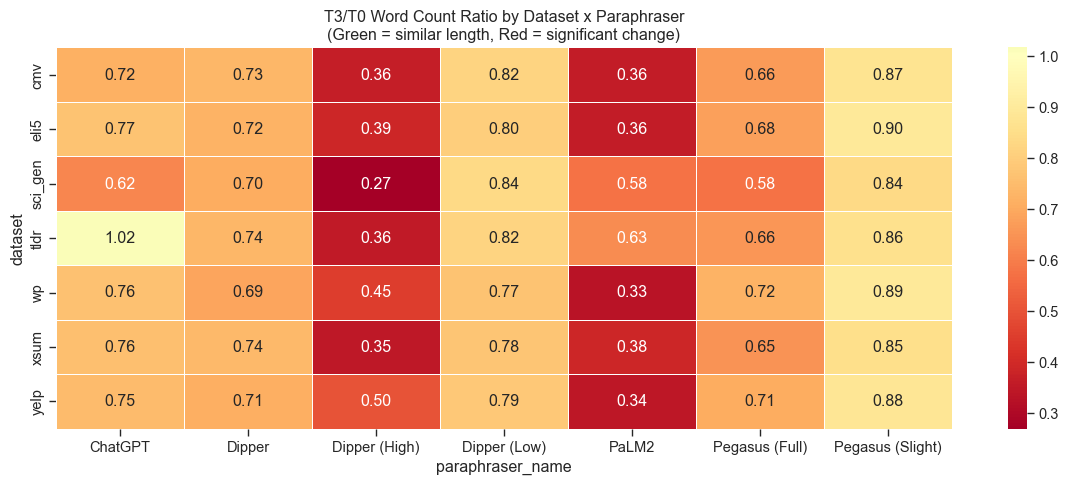

In [18]:
# Word count change: ratio of T3 avg to T0 avg, per dataset and paraphraser
t0_means = corpus[corpus["tier"] == "T0"].groupby("dataset")["word_count"].mean()
t3_by_ds_para = (corpus[corpus["tier"] == "T3"]
                 .groupby(["dataset", "paraphraser_name"])["word_count"].mean()
                 .reset_index())
t3_by_ds_para["t0_mean"] = t3_by_ds_para["dataset"].map(t0_means)
t3_by_ds_para["length_ratio"] = t3_by_ds_para["word_count"] / t3_by_ds_para["t0_mean"]

pivot_lr = t3_by_ds_para.pivot_table(
    index="dataset", columns="paraphraser_name", values="length_ratio"
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_lr, annot=True, fmt=".2f", cmap="RdYlGn", center=1.0,
            ax=ax, linewidths=0.5)
ax.set_title("T3/T0 Word Count Ratio by Dataset x Paraphraser\n(Green = similar length, Red = significant change)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda" / "t3_t0_length_ratio_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Per-dataset TTR comparison

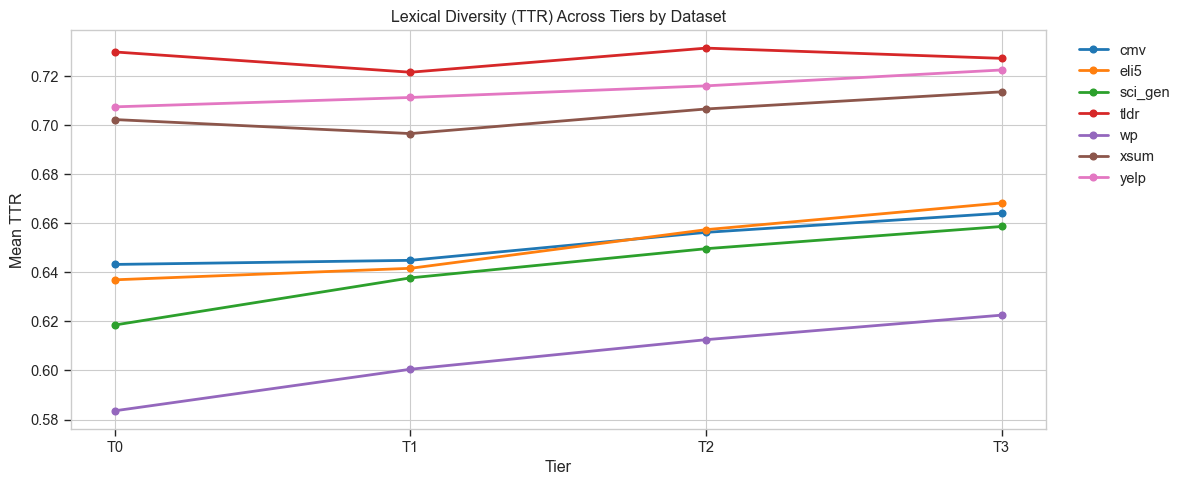

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
ds_tier_ttr = (plot_data.groupby(["dataset", "tier"])["ttr"]
               .mean().reset_index())

for ds in ALL_DATASETS:
    ds_data = ds_tier_ttr[ds_tier_ttr["dataset"] == ds]
    ax.plot(["T0", "T1", "T2", "T3"],
            ds_data.set_index("tier").reindex(tiers)["ttr"].values,
            marker="o", linewidth=2, label=ds)

ax.set_xlabel("Tier"); ax.set_ylabel("Mean TTR")
ax.set_title("Lexical Diversity (TTR) Across Tiers by Dataset")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda" / "ttr_by_dataset.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 8. Summary


**Corpus structure:**
- 66,400 rows after preprocessing. 3,020 T0 originals, ~21K rows each for T1/T2/T3.
- Balanced across paraphrasers (~3,020 per variant per tier). PaLM2 has slightly fewer due to generation failures.
- 7 source authors at T0: Human (511), OpenAI (468), LLAMA (464), Tsinghua (447), BigScience (428), PaLM (378), Eleuther-AI (324).
- Zero nulls, zero empty texts. Clean dataset.

**Text characteristics:**
- Paraphrasing consistently shortens text: avg word count drops from 279 (T0) to 221 (T1) to 198 (T2) to 184 (T3).
- Avg sentence length also decreases slightly: 16.0 (T0) to 14.6 (T3) words per sentence.
- Dipper (High) and PaLM2 shrink text most aggressively (T3/T0 ratio of 0.27-0.38). Pegasus (Slight) and Dipper (Low) preserve length best (0.82-0.90).

**Vocabulary shifts:**
- TTR increases slightly across tiers, meaning paraphrased text uses *more* diverse vocabulary relative to length. This is likely a side effect of text shortening (fewer repetitions).
- Punctuation decays monotonically: exclamation marks drop ~63% from T0 to T3, semicolons drop ~36%, question marks ~35%. Commas are most resilient (~18% drop).
- Dipper (High) and Pegasus (Full) actually *increase* punctuation density at T3, suggesting they inject their own punctuation style.
- PaLM2 and ChatGPT strip punctuation the most.

**Source author profiles:**
- Large variation in T0 originals: Tsinghua produces the longest texts (460 avg words), Eleuther-AI the shortest (127).
- Eleuther-AI has the highest TTR (0.94), suggesting shorter, more diverse vocabulary. Tsinghua has the lowest (0.44), consistent with longer, more repetitive text.
- Human text sits in the middle for most metrics but has the highest punctuation density (0.030).

**Per-dataset variation:**
- sci_gen is the most affected by Dipper (High) (0.27 length ratio), while tldr is the most resilient to ChatGPT (1.02 ratio).
- TTR trends are consistent across all 7 datasets: slight upward drift from T0 to T3.

**Word frequency shifts (yelp/ChatGPT example):**
- T0 top words are informal/personal: 'you', 'very', 'great', 'good', 'it\\'s', 'really', 'she', 'like'
- T3 top words shift to formal/generic: 'however,', 'despite', 'while', 'experience', 'recommend', 'staff'
- This is direct evidence of style laundering: personal voice replaced by generic LLM register.

These findings inform the similarity analysis in Notebook 02 and provide early evidence for RQ1 (style decays faster than content).

In [20]:
print(f"EDA complete. {len(corpus):,} documents explored across {len(ALL_DATASETS)} datasets.")

EDA complete. 66,400 documents explored across 7 datasets.
